## Import all the required libraries

In [23]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

## Get the dataset 

In [2]:
df = pd.read_csv(r"Simple linear regression.csv")
df

,SAT,GPA
0,1714,2.40
1,1664,2.52
2,1760,2.54
3,1685,2.74
4,1693,2.83
...,...,...
95,1934,3.54
96,1861,3.58
97,1931,3.58
98,1933,3.59


## Understand Data

In [3]:
df["SAT"].unique()

array([1714, 1664, 1760, 1685, 1693, 1670, 1764, 1792, 1850, 1735, 1775,
       1712, 1773, 1872, 1755, 1674, 1842, 1786, 1761, 1722, 1663, 1687,
       1974, 1826, 1787, 1821, 2020, 1794, 1769, 1934, 1855, 1880, 1849,
       1808, 1954, 1777, 1831, 1865, 1966, 1702, 1990, 1925, 1824, 1956,
       1857, 1979, 1802, 1907, 1634, 1879, 1887, 1730, 1953, 1781, 1891,
       1964, 1893, 2041, 1832, 1861, 1931, 1933, 1778, 1975, 2021, 2015,
       1997, 1843, 1936, 1810, 1987, 1962, 2050])

In [4]:
df["GPA"].unique()

array([2.4 , 2.52, 2.54, 2.74, 2.83, 2.91, 3.  , 3.01, 3.02, 3.07, 3.08,
       3.12, 3.17, 3.19, 3.2 , 3.21, 3.24, 3.28, 3.29, 3.31, 3.32, 3.34,
       3.37, 3.38, 3.39, 3.4 , 3.41, 3.42, 3.44, 3.47, 3.48, 3.49, 3.5 ,
       3.51, 3.52, 3.54, 3.58, 3.59, 3.6 , 3.61, 3.62, 3.64, 3.65, 3.71,
       3.73, 3.76, 3.81])

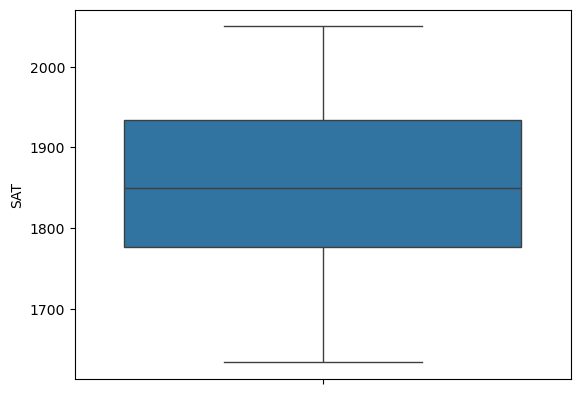

In [5]:
sns.boxplot(df["SAT"])
plt.show()

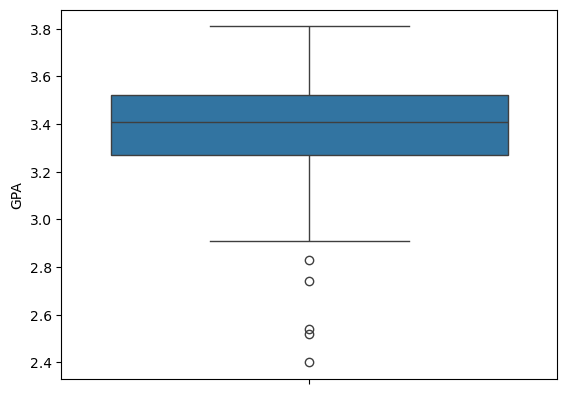

In [6]:
sns.boxplot(df["GPA"])
plt.show()

In [7]:
lower = df["GPA"].quantile(0.25) - 1.5*(df["GPA"].quantile(0.75) - df["GPA"].quantile(0.25))
lower

np.float64(2.895)

In [8]:
outliers = df[(df["GPA"] < lower)]
outliers

,SAT,GPA
0,1714,2.40
1,1664,2.52
2,1760,2.54
3,1685,2.74
4,1693,2.83


## Applying lower-side winsorization to cap extreme low GPA values using the IQR method

In [29]:
df["GPA"] = df["GPA"].clip(lower=lower)

In [30]:
# check where outliers values are handled
df[(df["GPA"] < lower)]

,SAT,GPA


## Lower extreme GPA values were capped using winsorization to reduce outlier influence and improve regression model stability

In [44]:
# Creating a scatter plot to visualize the relationship between SAT scores and GPA

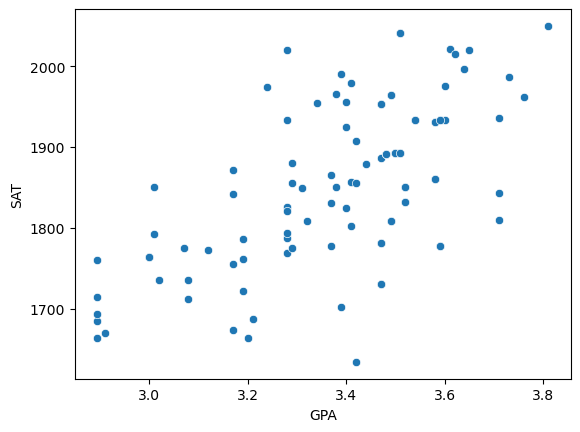

In [31]:
sns.scatterplot(x = df["GPA"],y=df["SAT"])
plt.show()

## Model Building 

In [32]:
x = df[["SAT"]] # Independent variable converting it into a 2D structure for model training
y = df["GPA"] # Dependent variable y = mx + c

In [33]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2,random_state=42)
xtrain,xtest,ytrain,ytest 

(     SAT
 55  1887
 88  1964
 26  1787
 42  1966
 69  1931
 ..   ...
 60  1964
 71  1778
 14  1773
 92  1893
 51  1855
 
 [80 rows x 1 columns],
      SAT
 83  2050
 53  1634
 70  1933
 45  1925
 44  1990
 39  1831
 22  1663
 80  1810
 10  1735
 0   1714
 18  1842
 30  1769
 73  1934
 33  1855
 90  1893
 4   1693
 76  1997
 77  2020
 12  1735
 31  1934,
 55    3.47
 88    3.49
 26    3.28
 42    3.38
 69    3.58
       ... 
 60    3.49
 71    3.59
 14    3.12
 92    3.51
 51    3.42
 Name: GPA, Length: 80, dtype: float64,
 83    3.810
 53    3.420
 70    3.590
 45    3.400
 44    3.390
 39    3.370
 22    3.200
 80    3.710
 10    3.020
 0     2.895
 18    3.170
 30    3.280
 73    3.600
 33    3.290
 90    3.500
 4     2.895
 76    3.640
 77    3.650
 12    3.080
 31    3.280
 Name: GPA, dtype: float64)

## Creating a Simple Linear Regression model object

In [34]:
slr = LinearRegression()

In [35]:
slr.fit(xtrain,ytrain)

LinearRegression()

In [36]:
slr.coef_

array([0.00130495])

In [37]:
slr.intercept_

np.float64(0.9627132338352995)

## Get the prediction with xtest

In [38]:
ypred = slr.predict(xtest)
ypred

array([3.63786146, 3.09500211, 3.48518227, 3.47474266, 3.55956444,
       3.35207733, 3.13284567, 3.32467337, 3.2268021 , 3.19939814,
       3.36643178, 3.27117041, 3.48648722, 3.38339614, 3.43298425,
       3.17199418, 3.56869909, 3.59871295, 3.2268021 , 3.48648722])

In [39]:
mae = mean_absolute_error(ytest, ypred)
mse = mean_squared_error(ytest, ypred)
rmse = np.sqrt(mse)
r2 = r2_score(ytest, ypred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 0.15299613161675812
MSE : 0.03413518947278043
RMSE : 0.18475710939712287
R2 Score : 0.48655183191332374


In [40]:
mae = mean_absolute_error(ytest, ypred)
mae

0.15299613161675812

In [41]:
mse = mean_squared_error(ytest, ypred)
mse

0.03413518947278043

In [42]:
rmse = np.sqrt(mse)
rmse 

np.float64(0.18475710939712287)

In [43]:
r2 = r2_score(ytest, ypred)
r2

0.48655183191332374

In [45]:
accuracy = round(r2 * 100,2)
print("Accuracy of the model :",accuracy)

Accuracy of the model : 48.66


# Conclusion:
## The Simple Linear Regression model was successfully built to predict GPA using SAT scores.
## The model achieved an R² score of 48.66%, indicating a moderate positive linear relationship.
## Lower outliers in GPA were handled using winsorization to improve model stability.

In [46]:
# Without outlier capping, the model accuracy was approximately 41%